# 7장 : 새와 비행기 구별하기 : 이미지 학습

 + 순방향 신경망 만들기
 + Dataset과 DataLoader를 사용한 데이터 로딩
 + 분류 손실

7장에서는 이미지를 다뤄보면서 신경망에 대한 기초를 더 다져본다.

앞에서처럼 단순 신경망을 만들어 간단한 이미지 인식 문제를 단계별로 접근해 나아간다.

## 7.1 작은 이미지를 모아 놓은 데이터셋

CIFAR-10은 $32 \times 32$크기의 컬러(RGB) 이미지 6만 개로 구성되어 있고 1에서 10까지의 정수로 레이블이 매겨져 있다. 0은 비행기, 1은 자동차, 2는 새, 3은 고양이, 4는 사슴, 5는 강아지, 6은 개구리, 7은 말, 8은 배, 9는 트럭이다.

오늘날 CIFAR-10은 새로운 연구를 위한 개발이나 검증으로 사용하기에 너무 단순하지만 학습용으로는 좋다.

### 7.1.1 CIFAR-10 다운로드

`torchvision` 모듈을 사용해서 다운 받는다.

In [1]:
from torchvision import datasets
import sys, os
BASE_DIR = os.getcwd()
sys.path.append(BASE_DIR)
data_path = os.path.join(BASE_DIR, "data", "data-unversioned", "p1ch7")
os.makedirs(data_path, exist_ok=True)

# CIFAR10 함수 : 첫 번째 인자 = 데이터를 받을 위치, 두 번째 인자 = 훈련셋인지 검증셋인지 지정, 
# 세 번째 인자 = 데이터를 찾지 못한 경우 첫번째 인자 위치에 데이터를 내려받으라고 지정
cifar10 = datasets.CIFAR10(data_path, train=True, download = True)
cifar10_val = datasets.CIFAR10(data_path, train=False, download = True)

`datasets` 서브모듈은 CIFAR10은 물론이고 MNIST, Fashion-MNIST, CIFAR-100, SVHN, Coco, Omniglot 등의 가장 인기 있는 컴퓨터 비전 데이터셋에 미리 짜여진 절차에 따라 접근할 수 있다.

각 경우에 데이터셋은 `torch.utils.data.Dataset`의 서브클래스로 반환된다.

`cifar10`인스턴스의 메소드를 분석해보면 기본 클래스로 포함된 것을 확인할 수 있다.

In [2]:
type(cifar10).__mro__

(torchvision.datasets.cifar.CIFAR10,
 torchvision.datasets.vision.VisionDataset,
 torch.utils.data.dataset.Dataset,
 typing.Generic,
 object)

### 7.1.2 데이터셋 클래스

파이토치 `Dataset`은 `__len__`과 `__getitem__`을 구현하기 위해 필요한 객체다. `__len__`은 데이터셋의 아이템 수를 반환해야 하고, `__getitem__`은 샘플과 레이블(정수 인덱스)로 이루어진아이템을 반환해야 한다.

In [3]:
len(cifar10)

50000

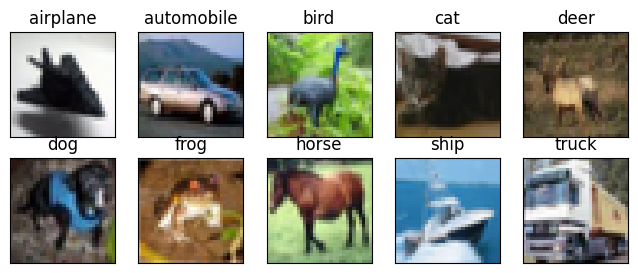

(<PIL.Image.Image image mode=RGB size=32x32>, 1, 'automobile')

In [4]:
import matplotlib.pyplot as plt

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

fig = plt.figure(figsize=(8,3))
num_classes = 10
for i in range(num_classes):
    ax = fig.add_subplot(2, 5, 1 + i, xticks=[], yticks=[])
    ax.set_title(class_names[i])
    img = next(img for img, label in cifar10 if label == i)
    plt.imshow(img)
plt.show()



img, label = cifar10[99]
img, label, class_names[label]

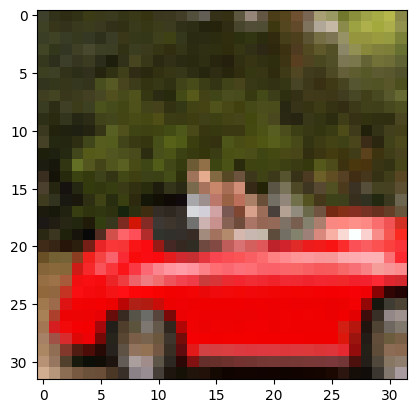

In [5]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.show()

### 7.1.3 데이터 변환

`data.CIFAR10` 데이터셋 샘플은 RGB PIL 이미지 객체라서 위와 같이 바로 그려볼 수 있고, 이러한 PIL 이미지를 파이토치 텐서로 변환해본다.

변환을 위해선 `torchvision.transforms`가 필요하다.

이 모듈은 재구성 가능한 함수 형태의 여러 객체를 정의하고 있어서 `datasets.CIFAR10(...)`과 같은 `torchvision` 데이터셋에 인자로 전달할 수 있고 로드한 다음에 `__getitem__`이 결과를 반환하기에, 이에 앞서 변환을 수행한다.

In [6]:
# torchvision에 사용가능한 객체
from torchvision import transforms
dir(transforms)

['AugMix',
 'AutoAugment',
 'AutoAugmentPolicy',
 'CenterCrop',
 'ColorJitter',
 'Compose',
 'ConvertImageDtype',
 'ElasticTransform',
 'FiveCrop',
 'GaussianBlur',
 'Grayscale',
 'InterpolationMode',
 'Lambda',
 'LinearTransformation',
 'Normalize',
 'PILToTensor',
 'Pad',
 'RandAugment',
 'RandomAdjustSharpness',
 'RandomAffine',
 'RandomApply',
 'RandomAutocontrast',
 'RandomChoice',
 'RandomCrop',
 'RandomEqualize',
 'RandomErasing',
 'RandomGrayscale',
 'RandomHorizontalFlip',
 'RandomInvert',
 'RandomOrder',
 'RandomPerspective',
 'RandomPosterize',
 'RandomResizedCrop',
 'RandomRotation',
 'RandomSolarize',
 'RandomVerticalFlip',
 'Resize',
 'TenCrop',
 'ToPILImage',
 'ToTensor',
 'TrivialAugmentWide',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_functional_pil',
 '_functional_tensor',
 '_presets',
 'autoaugment',
 'functional',
 'transforms']

이 중에 `ToTensor`라는 게 있는데, 넘파이 배열과 PIL 이미지를 텐서로 바꾸는 역할을 한다. 

뿐만 아니라 출력 텐서의 차원 레이아웃을 $C \times H \times W$ (4장에서 다룬 채널, 높이, 너비를 뜻한다)로 맞춰 준다.

In [7]:
# ToTensor 변환
from torchvision import transforms

to_tensor = transforms.ToTensor()
img_t = to_tensor(img)
img_t.shape # C = 3, H =32, W = 32

torch.Size([3, 32, 32])

In [8]:
# 변환 자체를 dataset.CIFAR10의 인자로 전달하기
tensor_cifar10 = datasets.CIFAR10(data_path, train=True, download=False, transform = transforms.ToTensor())

In [9]:
img_t, _ = tensor_cifar10[99]
type(img_t)

torch.Tensor

In [11]:
import torch
img_t: torch.Tensor

In [12]:
img_t.shape, img_t.dtype

(torch.Size([3, 32, 32]), torch.float32)

In [13]:
# 원본 PIL 이미지 값 범위 : [0, 255] -> tensor 값 범위(채널당 32 비트 부동소수점 형태) : [0.0, 1.0]
img_t.min(), img_t.max()

(tensor(0.), tensor(1.))

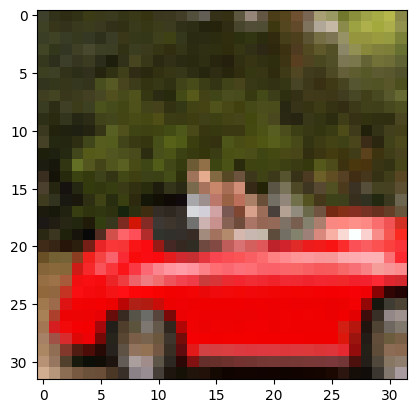

In [ ]:
# tensor 시각화 (matplotlib이 기대하는 H x W x C 형태를 위해서 permute를 사용)
plt.imshow(img_t.permute(1, 2, 0)) # (C, H, W) -> (H, W, C) 형태로 바꾸기
plt.show()

### 7.1.4 데이터 정규화

변환 기능은 매우 유용한데 특히 `transforms.Compose`로 여러 변환을 엮어서 사용할 때 더욱 그렇다.

`transforms.Compose`를 잘 사용하면 정규화와 $\text{데이터 증강}^{\text{data augmentation}}$도 데이터 로딩과 함께 수행할 수 있다.

모든 채널이 평균값 0과 단위 표준편차를 가지도록 데이터셋의 각 채널의 평균과 표준편차를 계산해서 `v_n[c] = (v[c] - mean[c]) / stdev[c]`변환을 적용하면 되는데 이게 바로 `transforms.Normalize`가 하는 일이다. `mean`과 `stdev`는 계산해주지 않으니 따로 계산해야 한다.
CIFAR-10 훈련셋으로 계산해보자.

참고로 CIFAR-10 데이터셋은 크기가 작아서, 필요한 모든 변환을 메모리 내에서 한꺼번에 다 할 수 있다(데이터 크기가 커지면 on-the-fly 형식이나, 쪼개서 for문으로 해야 할듯)

In [15]:
imgs = torch.stack([img_t for img_t, _ in tensor_cifar10], dim = 3) # img : (C, H, W) -> imgs : (C, H, W, N)
imgs.shape

torch.Size([3, 32, 32, 50000])

In [16]:
imgs.view(3, -1).mean(dim = 1) # 채널별로, 32x32x50000개의 픽셀들 전체의 평균계산. 사실상 cifar10 전체 이미지들의 채널별 평균을 계산하는것

tensor([0.4914, 0.4822, 0.4465])

In [17]:
imgs.view(3, -1).std(dim = 1) # 채널별로, 32x32x50000개의 픽셀들 전체의 표준편차 계산

tensor([0.2470, 0.2435, 0.2616])

In [18]:
# Normalize 변환 초기화
transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))

Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.247, 0.2435, 0.2616))

In [19]:
# Compose를 통한 totensor, normalize 한꺼번에 하기
transformed_cifar10 = datasets.CIFAR10(
    data_path, train=True, download=False,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                             (0.2470, 0.2435, 0.2616))
    ]))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9802876..2.1264887].


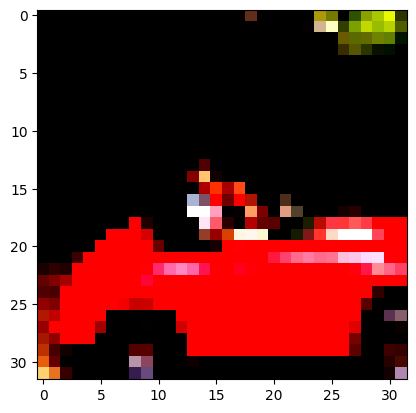

In [20]:
# 변환된 이미지 시각화
img_t, _ = transformed_cifar10[99]

plt.imshow(img_t.permute(1, 2, 0))
plt.show()

## 7.2 새와 비행기를 구별하기

$\textbf{Problem setting}$

 조류 관찰자가 공항 남쪽 숲에 카메라를 설치해서, 새 사진을 자동으로 찍고 실시간 탐조 블로그에 업로드하는 중이다. 문제는 카메라 렌즈안에 아무거나 들어와도(예 : 비행기) 그 사진을 찍느라, 블로그에서 비행기 사진을 삭제하는데 많은 시간이 소모되고 있다. 여기서 필요한게 자동화된 시스템이다. 수동으로 사진을 삭제하는 대신 비행기 사진을 자동으로 지워 주는 신경망, 즉 마케팅 용어로 'AI'가 필요하다.

다행히 해당 문제에 딱 맞는 데이터셋을 가지고 있다(CIFAR-10). CIFAR-10에서 새와 비행기를 골라낸 후 신경망을 만들어 새와 비행기를 구분해 보자.

### 7.2.1 데이터셋 구축

새와 비행기만 들어간 `Dataset`서브 클래스를 만들면 된다. 그런데 데이터셋은 작고 인덱싱과 `len`만 있으면 되므로 굳이 `Dataset`서브 클래스일 필요는 없다. 다음 코드를 보자.

In [32]:
import numpy as np
import torch

torch.set_printoptions(edgeitems=2)
torch.manual_seed(123)

In [ ]:
cifar10 = datasets.CIFAR10(
    data_path, train=True, download=False,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                             (0.2470, 0.2435, 0.2616))
    ]))

cifar10_val = datasets.CIFAR10(
    data_path, train=False, download=False,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                             (0.2470, 0.2435, 0.2616))
    ]))

In [34]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

label_map = {0: 0, 2: 1} # 0 : 비행기 -> 0으로 매핑, 2 : 새 -> 1로 매핑
class_names = ['airplane', 'bird']
cifar2 = [(img, label_map[label]) for img, label in cifar10 if label in [0, 2]] # 리스트 컴프리헨션을 통한 데이터 재구축 및 레이블 매핑
cifar2_val = [(img, label_map[label]) for img, label in cifar10_val if label in [0, 2]] # 되게 깔끔하다. (이 방법 말고도 다양한 방법 가능)

### 7.2.2 완전 연결 모델

신경망은 결국 $\textbf{피처}^{\text{feature}}$ 텐서가 들어가고 피처 텐서가 나오는 것의 반복적인 구조이다.

생각해보면 이미지도 결국 공간 설정에 따라 적절하게 배치된 숫자 집합일 뿐이므로, 아주 간단하게 이미지 픽셀을 받아서 긴 1차원의 벡터로 늘어뜨린다면 결국 일련의 숫자들을 입력 피처로 볼 수 있을 것이다.

이런식으로 진행하게 되면 샘플마다 $3 \times 32 \times 32$이니까 3,072개의 입력 피처가 있는 셈이다.

새로운 모델은 `nn.Linear`이면서 입력 피처가 3,072이고 몇 개의 히든 피처를 거쳐 활성 함수로 이어지도록 만들자. 이후 다른 `nn.Linear`로 신경망을 줄여나가면서 원하는 출력 피처 수로 맞추자.

In [35]:
import torch.nn as nn

n_out = 2 # 새인지 비행기인지, 최종 구분을 위해서 2로 설정

model = nn.Sequential(
    nn.Linear(3072, 512),
    nn.Tanh(),
    nn.Linear(512, n_out)
)

### 7.2.3 분류기의 출력

6장에서는 신경망이 예측 온도값을 출력으로 만들어냈다. 이번에도 이와 비슷하게 할 수 있다.

신경망이 단일한 스칼라값(`n_out = 1`)을 출력하게 만들고 레이블을 부동소수점 수로 변환한 후(비행기는 0.0, 새는 1.0) 이를 `MSELoss`(배치상에서 실측값과 출력값의 차이를 제곱한 값의 평균)의 타깃으로 사용한다. 이렇게 해서 이 문제를 회귀 문제로 만든다. 그런데 과연 회귀로 푸는게 맞을까?

출력값이 카테고리라는 것을 인식할 필요가 있다. 출력값은 언제나 새 혹은 비행기일 뿐이다(원래대로 10개 클래스를 대상으로 했다면 다른 값이 나올 수도 있긴 하다). 4장에서 다룬 것처럼 카테고리 변수를 표현할 때는 `[1, 0]`을 비행기, `[0, 1]`을 새로 하는 것처럼 원핫 인코딩으로 바꿔줘야 한다(순서는 상관없다. 매핑을 맞춰주면 되므로). CIFAR-10 전체 데이터셋에 대한 클래스 10을 사용하는 경우도 마찬가지다. 이때라면 길이가 10인 벡터를 사용한다.

이상적인 경우 신경망은 비행기에 대해 `torch.tensor([1.0, 0.0])`을 출력하고 새에 대해 `torch.tensor([0.0, 1.0])`을 출력한다. 실제로 우리 분류기는 완벽하지 않으므로 신경망의 출력은 두 값 사이가 될 것이다. 중요한 포인트는 출력을 확률로 해석할 수 있다는 점이다. 첫 번째 값은 '비행기'일 확률, 두 번째 값은 '새'일 확률이다.

문제를 확률로 보게 되면 신경망의 출력에 추가적인 제약을 수반한다(확률의 공리).

 - 출력값의 요소가 가질 수 있는 값은 `[0.0, 1.0]` 범위로 제한된다(확률은 0보다 작거나 1보다 클 수 없으므로),
 - 모든 출력 요소의 값의 합은 1.0이다(결과는 항상 새 아니면 비행기라고 확신한다).

숫자 벡터를 미분 가능하게 해야 하는 것 치고는 가혹한 제한처럼 보일 수 있다. 이런 제약을 극복하면서 미분 가능하게 만드는 똑똑한 방법이 있는데, 바로 $\textbf{소프트맥스}^{\text{softmax}}$라 부르는 방법이다.

### 7.2.4 출력을 확률로 표현하기

소프트맥스는 벡터값을 받아 동일한 차원의 다른 벡터를 만드는데, 값이 확률로 표현되어야 하는 제약을 만족한다.

소프트맥스는 벡터의 각 요소 단위로 지수 연산 후 각 요소를 지수 값의 총합으로 나눈다.

\begin{align*}
    \text{softmax}(x_1, x_2) &= \left( \cfrac{e^{x_1}}{e^{x_1} + e^{x_2}}, \cfrac{e^{x_2}}{e^{x_1} + e^{x_2}} \right) \\
    \text{softmax}(x_1, x_2, x_3) &= \left( \cfrac{e^{x_1}}{e^{x_1} + e^{x_2} + e^{x_3}}, \cfrac{e^{x_2}}{e^{x_1} + e^{x_2} + e^{x_3}}, \cfrac{e^{x_3}}{e^{x_1} + e^{x_2} + e^{x_3}} \right) \\
    \vdots  \\
    \text{softmax}(x_1, \ldots, x_n) &= \left( \cfrac{e^{x_1}}{e^{x_1} + \cdots + e^{x_n}}, \cdots, \cfrac{e^{x_n}}{e^{x_1} + \cdots + e^{x_n}} \right) \\
\end{align*}



In [36]:
# 소프트맥스 구현
def softmax(x):
    return torch.exp(x) / torch.exp(x).sum()

In [37]:
# 테스트
x = torch.tensor([1.0, 2.0, 3.0])
print(softmax(x))

# 확률합=1 만족
print(softmax(x).sum())

tensor([0.0900, 0.2447, 0.6652])
tensor(1.)


In [38]:
# nn모듈의 소프트맥스 모듈 : nn.Softmax (통상적으로 입력 텐서는 0번 차원 배치에 해당하거나 확률 값을 특정 차원에 대해서만 인코딩하므로
# nn.Softmax는 소프트맥스 함수를 적용할 차원을 지정하도록 요구한다)
softmax = nn.Softmax(dim = 1) # 1번째 차원에 대해서 소프트맥스 계산하도록 지정

x = torch.tensor([[1.0, 2.0, 3.0], [1.0, 2.0, 3.0]]) # (B, x) : 배치차원, 입력벡터. dim = 1이므로 입력벡터에 대한 소프트맥스를 계산.
softmax(x)

tensor([[0.0900, 0.2447, 0.6652],
        [0.0900, 0.2447, 0.6652]])

In [39]:
model = nn.Sequential(
    nn.Linear(3072, 512),
    nn.Tanh(),
    nn.Linear(512, 2),
    nn.Softmax(dim = 1))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8624594..2.0298588].


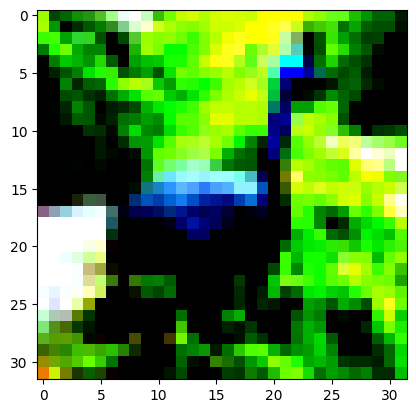

In [41]:
# 모델 훈련전에 한 번 이미지 초기화모델에 넣어보기
img, _ = cifar2[0]
img: torch.Tensor
plt.imshow(img.permute(1, 2, 0))
plt.show()

In [43]:
# 모델의 입력차원에 맞춰주기 위해 이미지를 1차원 텐서로 만들기
img_batch = img.view(-1).unsqueeze(0)
img_batch.shape

torch.Size([1, 3072])

In [ ]:
out = model(img_batch)
out # 여기서 출력된 숫자는 그 합이 1이고, 각각이 0과 1사이에 있는 어떤 값일 뿐, 그 자체로 의미를 갖지는 않는 상태이다.

tensor([[0.4784, 0.5216]], grad_fn=<SoftmaxBackward0>)

In [45]:
# argmax로 출력된 확률값에 대해서 가장 높은 확률에 대한 인덱스 구하기 (torch.max)
_, index = torch.max(out, dim = 1)

index

tensor([1])

### 7.2.5 분류를 위한 손실값

분류문제는 결국 분류하고자 하는 클래스들에 대한 확률값을 구하는 것이 필요하므로 이러한 확률값 예측 문제를 회귀로 풀 수 있다. 즉 손실값으로 MSE를 사용해서 출력 확률이 `[0.0, 1.0]`과 `[1.0, 0.0]`에 수렴하도록 만들 수 있다.

그러나 결국 두 확률중 높은 값에 해당하는 클래스로 분류하는게 최종 목적이 되므로, 정확한 확률값 예측보다, 예측되는 확률값에 차이가 유의미하게 만들어지는게 더 중요하게 된다. 즉, 분류가 어긋나는 경우에 대해서 손실값을 계산하는게 더 의미가 있어진다.

$N$ 개의 사진에 대해서, $i$번째 사진 $x_i$가 레이블 $y_i = 1$ 이면 비행기, $y_i = 0$ 이면 새라고 하고 $p_i$ 를 비행기일 확률, $(1-p_i)$ 를 새일 확률이라고 하자. 그러면 

\begin{equation*}
    f(y_i|x_i) = p_i^{y_i}(1-p_i)^{1-y_i}, \quad i=1,\ldots,N
\end{equation*}

와 같이 $i$ 번째 사진에 대한 새혹은 비행기일 베르누이 확률분포를 가정할 수 있다. 각 사진이 독립이라고 가정하고 로그가능도함수를 구하면


\begin{equation*}
    l(p) = \text{ln} \left( \displaystyle\prod_{i=1}^{N}f(y_i|x_i) \right) = \displaystyle\sum_{i=1}^{N} \left( y_i \text{ln}p_i + (1 - y_i) \text{ln}(1-p_i) \right) = \displaystyle\sum_{i=1}^{N} \displaystyle\sum_{k=1}^{2}  y_{i, k} \text{ln}p_{i,k}
\end{equation*}

\begin{equation*}
    \quad y_{i, 1} = y_i,\quad y_{i,2} = (1-y_i), \quad p_{i,1} = p_i,\quad p_{i,2} = (1-p_i)
\end{equation*}

이 되는데, 이 로그가능도함수가 주어진 데이터에 대하여, 정답클래스에 대한 확률값들의 합(정확히는 로그합) 의미하게 된다.

이러한 로그가능도함수는 정답클래스에 대한 확률값이 높은 경우 (예를 들어 0.99) 가능도값이 0에 거의 가까워진다.

반대로 정답클래스에 대한 확률값이 낮은 경우 (예를 들어 0.01) 가능도값이 음의 값으로 매우 낮아진다.

이러한 로그가능도함수에 마이너스 부호를 붙인 $-l(p) = - \displaystyle\sum_{i=1}^{N} \displaystyle\sum_{k=1}^{2}  y_{i, k} \text{ln}p_{i,k}$ 는 정답클래스에 대한 확률값이 낮아지면 값이 커지고, 정답클래스에 대한 확률값이 높아지면 값이 낮아지기에, 일종의 손실함수로서 사용이 가능하다(정답을 맞추면 손실이 낮아지고, 틀리면 손실이 커지므로).

이러한 함수를 $\text{음의 로그가능도}^{Negative Log Likelihood}$라고 한다. 이 예제의 경우 이진분류로서 확률분포로 베르누이분포를 사용하므로 특별히 Binary Cross Entropy 라고 한다.

파이토치에서는 이러한 음의로그가능도 NLL 에 대한 손실함수를 제공하며, NLL의 표현식은 간단히 `NLL = - sum(log(out_i[c_i]))`로 쓸 수 있다(이 때 `sum`은 $N$ 개 샘플 합, `c_i`는 샘플 $i$ 에 대한 정답 클래스).

$\textbf{분류를 위한 손실 계산 과정}$
  1. 순방향 전달 후 마지막(선형) 계층에서 출력값을 얻는다.
  2. 이들의 소프트맥스 값을 계산해서 확률을 얻는다.
  3. (파라미터의 가능도에 해당하는) 정답 클래스와 일치하는 예측 확률값을 얻는다. $\text{지도}^{\text{supervised}}$문제이기 때문에 실측값이 존재하므로, 정답 클래스를 안다고 가정할 수 있다.
  4. 로그값을 계산해서 앞에 마이너스를 붙인 다음 손실값에 더한다.

파이토치는 `nn.NLLLoss`클래스를 제공하는데, 확률 대신 로그 확률의 텐서를 입력으로 받고 데이터 배치에 대한 모델의 NLL을 계산한다. 입력 형식이 이러한 이유는 입력을 확률의 로그값으로 받으면, 확률이 0에 가까울 경우 문제가 생기는데, 이를 해결하기 위해 `nn.Softmax` 대신 `nn.LogSoftmax`를 사용함으로써 계산이 안정적으로 수행되게 한다. 

In [46]:
# nn.LogSoftmax를 출력 모듈로 사용한 모델
model = nn.Sequential(
    nn.Linear(3072, 512),
    nn.Tanh(),
    nn.Linear(512, 2),
    nn.LogSoftmax(dim = 1))

# NLL 손실값 초기화
loss = nn.NLLLoss()

In [47]:
img, label = cifar2[0]
img: torch.Tensor
out = model(img.view(-1).unsqueeze(0))
loss(out, torch.tensor([label]))

tensor(0.5079, grad_fn=<NllLossBackward0>)

크로스엔트로피손실은 예측이 타깃에서 멀어지는 경우 그래프의 경사가 적당히 생기지만, MSE는 훨씬 더 일찍 포화되어 그래프의 경사가 매우 커지고 좋지 않은 예측을 하게 된다.

근본적으로 MSE의 기울기는, 잘못된 예측에 대한 소프트맥스 함수의 평탄화를 보상하기에 너무 작다는 사실을 알 수 있다. 따라서 분류 문제에서 확률에 대해 MSE 손실을 사용하는 건 좋은 방법이 아니게 된다.

### 7.2.6 분류기 훈련

단일 샘플에서 부분적으로 기울기를 얻어 파라미터를 변경하는 경우, 하나의 샘플에 기반해서 손실 값을 줄이는 것이 다른 샘플에 대해서는 안 좋아질 수 있다. 그래서 각 에포크마다 샘플을 섞은 후 한 번에 하나 혹은(안정성을 고려해서) 여러 개의 샘플에 대해 기울기를 평가하면 경사 하강에 랜덤한 효과를 넣어줄 수 있다.

$\textbf{SGD}^{\text{stochastic gradient descent}}$ 의 S는 확률적이라는 의미로서, 섞은 데이터의 작은 배치(미니 배치)단위로 수행한다. 미니 배치에서 얻은 기울기를 사용하면 전체 데이터셋에 대한 값만큼 $\text{근사}^{\text{approximation}}$ 하지는 않지만, 훈련중에 만날지 모르는 $\text{지역 최솟값}^{\text{local minima}}$ 에 최적화 프로세스가 빠져버리는 것을 예방하고 수렴을 돕는 것으로 알려져 있다.

미니 배치에서의 기울기는 이상적인 궤적(전체 배치를 사용하는 경우의 기울기 궤적)에서 랜덤하게 떨어져 있고, 그래서 작은 학습률을 사용하여 이상한 궤적으로 크게 튀지 않도록 학습한다. 각 에포크에서 데이터셋을 섞으면 미니 배치에서 얻은 기울기의 시퀀스가 전체 데이터셋에서 계산한 기울기를 대표하도록 만드는 데 도움이 된다.

통상 미니 배치 크기는 학습률을 지정했던 것과 같이 훈련 전에 상수로 고정한다. 이와 같은 고정 값들은 모델의 파라미터와 구분하여 $\textbf{하이퍼파라미터}^{\text{hyperparameters}}$ 라 부른다.

In [49]:
# 내부 루프 안에서 한 번에 하나의 샘플을 평가하고 단일 샘플에 대해 역전파하기
import torch
import torch.nn as nn

model = nn.Sequential(
    nn.Linear(3072, 512),
    nn.Tanh(),
    nn.Linear(512, 2),
    nn.LogSoftmax(dim = 1))

learning_rate = 1e-2

optimizer = torch.optim.SGD(model.parameters(), lr = learning_rate)
loss_fn = nn.NLLLoss()

n_epochs = 100

for epoch in range(n_epochs):
    for img, label in cifar2:
        img: torch.Tensor
        out = model(img.view(-1).unsqueeze(0))
        loss = loss_fn(out, torch.tensor([label]))
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    print(f"Epoch:{epoch + 1}, Loss : {float(loss):.4f}")

C:\Users\PC\AppData\Local\Temp\ipykernel_26912\3259954884.py:28: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  print(f"Epoch:{epoch + 1}, Loss : {float(loss):.4f}")


Epoch:1, Loss : 5.9021
Epoch:2, Loss : 3.5852
Epoch:3, Loss : 3.2311
Epoch:4, Loss : 5.0831
Epoch:5, Loss : 4.2357
Epoch:6, Loss : 9.4599
Epoch:7, Loss : 13.1452
Epoch:8, Loss : 0.3941
Epoch:9, Loss : 8.9729
Epoch:10, Loss : 6.2757
Epoch:11, Loss : 5.7037
Epoch:12, Loss : 3.7565
Epoch:13, Loss : 5.5579
Epoch:14, Loss : 0.3890
Epoch:15, Loss : 8.0611
Epoch:16, Loss : 12.0240
Epoch:17, Loss : 13.6549
Epoch:18, Loss : 0.7789
Epoch:19, Loss : 3.8465
Epoch:20, Loss : 11.6547
Epoch:21, Loss : 12.8024
Epoch:22, Loss : 19.5956
Epoch:23, Loss : 15.3500
Epoch:24, Loss : 4.4813
Epoch:25, Loss : 7.6990
Epoch:26, Loss : 11.0416
Epoch:27, Loss : 9.2974
Epoch:28, Loss : 13.9109
Epoch:29, Loss : 9.9573
Epoch:30, Loss : 15.5880
Epoch:31, Loss : 8.1429
Epoch:32, Loss : 8.0879
Epoch:33, Loss : 18.6477
Epoch:34, Loss : 8.0497
Epoch:35, Loss : 16.9012
Epoch:36, Loss : 9.3023
Epoch:37, Loss : 8.2103
Epoch:38, Loss : 7.5924
Epoch:39, Loss : 10.4037
Epoch:40, Loss : 5.7762
Epoch:41, Loss : 21.1129
Epoch:42, L

위의 훈련 코드는 데이터셋에서 한 번에 하나의 아이템을 골라 크기가 1인 미니 배치를 만든다. `torch.utils.data` 모듈에는 미니 배치의 데이터를 섞거나 구조화하는 작업을 돕는 `DataLoader` 클래스가 있다. 

데이터 로더를 활용해서 데이터셋에서 미니 배치에 포함될 샘플을 가져올 때 여러 가지 샘플링 전략 중에서 하나를 고를 수 있다. 가장 흔한 전략은 각 에포크마다 데이터를 섞은 후 고르게 샘플링하는 것이다.

이를 어떻게 구현하는지 살펴보자. 먼저 `DataLoader` 생성자는 입력으로 `Dataset` 객체와 함께 `batch_size`와 `shuffle`을 입력받는다. `shuffle`은 불리언 값으로 데이터가 각 에포크마다 섞여야 할지를 지정한다.

In [50]:
import torch
import torch.nn as nn

# DataLoader는 순회 가능하므로 훈련루프안에 바로 넣어 사용할 수 있다.
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64, shuffle=True)

model_mini_batch = nn.Sequential(
    nn.Linear(3072, 512),
    nn.Tanh(),
    nn.Linear(512, 2),
    nn.LogSoftmax(dim = 1)
)

learning_rate = 1e-2
optimizer = torch.optim.SGD(model_mini_batch.parameters(), lr=learning_rate)
loss_fn = nn.NLLLoss()

n_epochs = 100

for epoch in range(n_epochs):
    for imgs, labels in train_loader:
        imgs: torch.Tensor
        batch_size = imgs.shape[0]
        outputs = model_mini_batch(imgs.view(batch_size, -1))
        loss = loss_fn(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    print(f"Epoch :{epoch + 1}, Loss : {float(loss):.4f}")

Epoch :1, Loss : 0.3980
Epoch :2, Loss : 0.5385
Epoch :3, Loss : 0.6039
Epoch :4, Loss : 0.3122
Epoch :5, Loss : 0.2220
Epoch :6, Loss : 0.4264
Epoch :7, Loss : 0.4616
Epoch :8, Loss : 0.2626
Epoch :9, Loss : 0.3323
Epoch :10, Loss : 0.2805
Epoch :11, Loss : 0.5657
Epoch :12, Loss : 0.6594
Epoch :13, Loss : 0.3243
Epoch :14, Loss : 0.3826
Epoch :15, Loss : 0.3201
Epoch :16, Loss : 0.4561
Epoch :17, Loss : 0.2831
Epoch :18, Loss : 0.2777
Epoch :19, Loss : 0.3096
Epoch :20, Loss : 0.3753
Epoch :21, Loss : 0.2799
Epoch :22, Loss : 0.5846
Epoch :23, Loss : 0.3341
Epoch :24, Loss : 0.3334
Epoch :25, Loss : 0.4737
Epoch :26, Loss : 0.1953
Epoch :27, Loss : 0.3346
Epoch :28, Loss : 0.1521
Epoch :29, Loss : 0.2058
Epoch :30, Loss : 0.3875
Epoch :31, Loss : 0.1072
Epoch :32, Loss : 0.1496
Epoch :33, Loss : 0.1393
Epoch :34, Loss : 0.1844
Epoch :35, Loss : 0.0852
Epoch :36, Loss : 0.1113
Epoch :37, Loss : 0.2604
Epoch :38, Loss : 0.0587
Epoch :39, Loss : 0.2114
Epoch :40, Loss : 0.1405
Epoch :41

In [51]:
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64, shuffle=False)

In [65]:
# mini-batch 크기 1인 경우
correct = 0
total = 0
with torch.no_grad():
    for img, label in val_loader:
        img: torch.Tensor
        label: torch.Tensor
        batch_size = img.shape[0]
        output = model(img.view(batch_size, -1))
        _, predicted = torch.max(output, dim = 1)
        total += label.shape[0]
        correct += int((predicted == label).sum())

print(f"Accuracy : {correct / total :.4f}")

Accuracy : 0.7505


In [67]:
# mini-batch 크기 64인 경우
correct = 0
total = 0
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64, shuffle=False)
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs: torch.Tensor
        labels: torch.Tensor
        batch_size = imgs.shape[0]
        outputs = model_mini_batch(imgs.view(batch_size, -1))
        _, predicted = torch.max(outputs, dim = 1)
        total += labels.shape[0]
        correct += int((predicted == labels).sum())

print(f"Accuracy : {correct / total :.4f}")

Accuracy : 0.8245


In [68]:
print(correct, total)

1649 2000


일반적으로 신경망의 마지막 계층에서는 `nn.LogSoftmax` 대신 손실값으로 `nn.CrossEntropyLoss`를 사용한다.

In [75]:
model_big = nn.Sequential(
    nn.Linear(3072, 1024),
    nn.Tanh(),
    nn.Linear(1024, 512),
    nn.Tanh(),
    nn.Linear(512, 128),
    nn.Tanh(),
    nn.Linear(128, 2)
)

loss_fn = nn.CrossEntropyLoss() # 모델의 출력값으로 nn.LogSoftmax, 손실함수를 nn.NLLLoss으로 사용하는 것과 동일하다

In [76]:
model_big = model_big.to(device="cuda")

learning_rate = 1e-2
optimizer = torch.optim.SGD(model_big.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss()

n_epochs = 100

for epoch in range(n_epochs):
    for imgs, labels in train_loader:
        imgs: torch.Tensor
        labels: torch.Tensor
        imgs = imgs.to(device="cuda")
        labels = labels.to(device = "cuda")
        batch_size = imgs.shape[0]
        outputs = model_big(imgs.view(batch_size, -1))
        loss = loss_fn(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    print(f"Epoch :{epoch + 1}, Loss : {float(loss):.4f}")

Epoch :1, Loss : 0.3422
Epoch :2, Loss : 0.2526
Epoch :3, Loss : 0.3083
Epoch :4, Loss : 0.2779
Epoch :5, Loss : 0.6419
Epoch :6, Loss : 0.3575
Epoch :7, Loss : 0.5745
Epoch :8, Loss : 0.2796
Epoch :9, Loss : 0.4430
Epoch :10, Loss : 0.3807
Epoch :11, Loss : 0.7221
Epoch :12, Loss : 0.6534
Epoch :13, Loss : 0.7502
Epoch :14, Loss : 0.4282
Epoch :15, Loss : 0.3666
Epoch :16, Loss : 0.3289
Epoch :17, Loss : 0.2007
Epoch :18, Loss : 0.4942
Epoch :19, Loss : 0.3246
Epoch :20, Loss : 0.3069
Epoch :21, Loss : 0.2152
Epoch :22, Loss : 0.3855
Epoch :23, Loss : 0.2609
Epoch :24, Loss : 0.2668
Epoch :25, Loss : 0.7379
Epoch :26, Loss : 0.2396
Epoch :27, Loss : 0.1522
Epoch :28, Loss : 0.2854
Epoch :29, Loss : 0.3515
Epoch :30, Loss : 0.1700
Epoch :31, Loss : 0.0680
Epoch :32, Loss : 0.2086
Epoch :33, Loss : 0.1981
Epoch :34, Loss : 0.1009
Epoch :35, Loss : 0.4912
Epoch :36, Loss : 0.1992
Epoch :37, Loss : 0.0799
Epoch :38, Loss : 0.0321
Epoch :39, Loss : 0.0520
Epoch :40, Loss : 0.0445
Epoch :41

In [77]:
# model_big inference
correct = 0
total = 0
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64, shuffle=False)
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs: torch.Tensor
        labels: torch.Tensor
        imgs = imgs.to(device="cuda")
        labels = labels.to(device="cuda")
        batch_size = imgs.shape[0]
        outputs = model_big(imgs.view(batch_size, -1))
        _, predicted = torch.max(outputs, dim = 1)
        total += labels.shape[0]
        correct += int((predicted == labels).sum())

print(f"Accuracy : {correct / total :.4f}")

Accuracy : 0.8105


오히려 정확도가 더 떨어졌다. 그리고 두 경우 모두 모델이 과적합하는 상황이다.

완전 연결 모델은 훈련셋을 암기하는 방식으로 비행기와 새를 구별하므로 더 큰 모델을 선택하더라도 검증셋의 성능은 그다지 좋지 못하다. (과연?)

In [78]:
model_Big = nn.Sequential(
    nn.Linear(3072, 1024),
    nn.ReLU(),
    nn.Dropout(p = 0.4),
    nn.Linear(1024, 1024),
    nn.ReLU(),
    nn.Dropout(p = 0.4),
    nn.Linear(1024, 512),
    nn.ReLU(),
    nn.Dropout(p = 0.4),
    nn.Linear(512, 512),
    nn.ReLU(),
    nn.Dropout(p = 0.4),
    nn.Linear(512, 128),
    nn.ReLU(),
    nn.Dropout(p = 0.4),
    nn.Linear(128, 2)
)

model_Big = model_Big.to(device="cuda")

learning_rate = 0.005
optimizer = torch.optim.SGD(model_Big.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss()

n_epochs = 200

for epoch in range(n_epochs):
    for imgs, labels in train_loader:
        imgs: torch.Tensor
        labels: torch.Tensor
        imgs = imgs.to(device="cuda")
        labels = labels.to(device = "cuda")
        batch_size = imgs.shape[0]
        outputs = model_Big(imgs.view(batch_size, -1))
        loss = loss_fn(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    print(f"Epoch :{epoch + 1}, Loss : {float(loss):.4f}")

Epoch :1, Loss : 0.6993
Epoch :2, Loss : 0.6880
Epoch :3, Loss : 0.6878
Epoch :4, Loss : 0.6780
Epoch :5, Loss : 0.6935
Epoch :6, Loss : 0.6519
Epoch :7, Loss : 0.6083
Epoch :8, Loss : 0.6398
Epoch :9, Loss : 0.5767
Epoch :10, Loss : 0.4619
Epoch :11, Loss : 0.4658
Epoch :12, Loss : 0.4793
Epoch :13, Loss : 0.4983
Epoch :14, Loss : 0.5265
Epoch :15, Loss : 0.3322
Epoch :16, Loss : 0.3679
Epoch :17, Loss : 0.4914
Epoch :18, Loss : 0.5223
Epoch :19, Loss : 0.5097
Epoch :20, Loss : 0.4374
Epoch :21, Loss : 0.5874
Epoch :22, Loss : 0.4265
Epoch :23, Loss : 0.8677
Epoch :24, Loss : 0.3494
Epoch :25, Loss : 0.4006
Epoch :26, Loss : 0.4994
Epoch :27, Loss : 0.3901
Epoch :28, Loss : 0.2957
Epoch :29, Loss : 0.3167
Epoch :30, Loss : 0.2891
Epoch :31, Loss : 0.4633
Epoch :32, Loss : 0.1776
Epoch :33, Loss : 0.2397
Epoch :34, Loss : 0.1414
Epoch :35, Loss : 0.2194
Epoch :36, Loss : 0.1048
Epoch :37, Loss : 0.2967
Epoch :38, Loss : 0.3337
Epoch :39, Loss : 0.3233
Epoch :40, Loss : 0.3241
Epoch :41

In [136]:
# model_Big inference

model_Big.eval()

correct = 0
total = 0
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64, shuffle=False)
with torch.no_grad():
    for imgs, labels in val_loader:
        imgs: torch.Tensor
        labels: torch.Tensor
        imgs = imgs.to(device="cuda")
        labels = labels.to(device="cuda")
        batch_size = imgs.shape[0]
        outputs = model_Big(imgs.view(batch_size, -1))
        _, predicted = torch.max(outputs, dim = 1)
        total += labels.shape[0]
        correct += int((predicted == labels).sum())

print(f"Accuracy : {correct / total :.4f}")

Accuracy : 0.8675


파이토치는 `nn.Model`의 `parameters()` 메소드를 통해 모델이 얼마나 많은 파라미터를 가지고 있는지를 빠르게 확인할 수 있다.

특히 각 텐서 객체에 얼마나 많은 요소가 있는지 확인하려면 `numel`메소드를 사용한다. 그렇게 얻은 값을 합산하면 전체 수 파악이 가능하다.

파라미터 수를 세려면 파라미터에 대해 `requires_grad`가 `True`로 설정되었는지도 확인해야 한다.

전체 모델 크기 대비 학습 가능한 파라미터의 수는 구별되어야 하기 때문이다.

In [80]:
# 첫 번째 모델
numel_list = [p.numel()
              for p in model_mini_batch.parameters()
              if p.requires_grad == True]
print(f"1st model : {sum(numel_list), numel_list}")

# 두 번째 모델
numel_list = [p.numel()
              for p in model_big.parameters()
              if p.requires_grad == True]
print(f"2nd model : {sum(numel_list), numel_list}")

# 세 번째 모델
numel_list = [p.numel()
              for p in model_Big.parameters()
              if p.requires_grad == True]
print(f"3rd model : {sum(numel_list), numel_list}")

1st model : (1574402, [1572864, 512, 1024, 2])
2nd model : (3737474, [3145728, 1024, 524288, 512, 65536, 128, 256, 2])
3rd model : (5049730, [3145728, 1024, 1048576, 1024, 524288, 512, 262144, 512, 65536, 128, 256, 2])


결론 : 우리의 신경망이 픽셀 수에 따라 확장 가능하기 어렵다(물론 dropout, regularization, perturbation등 각종 테크닉 사용하면 얘기가 좀 달라지긴 한다)

만약 이미지가 $1,024 \times 1,024$ RGB 이미지라면 어떻게 될까? 입력값이 3*1024*1024로 이미 대략 310만개가 되고, 1024개의 은닉된 피처로 들어가게 될 것이다. 그러면 대략 30억 개의 파라미터를 가지게 된다(wow). 32비트 부동소수점을 사용하면 기울기 계산을 위해 더 많은 연산과 저장 공간이 필요한 두 번째 계층을 거치기도 전에 12기가 램 영역이 필요하게 된다(그것도 미니배치 크기가 1인 경우에!).

### 7.2.7 완전 연결의 한계

이미지를 1차원으로 놓고 선형 모듈을 사용하는 방식에 대해 좀 더 곰곰이 생각해보자. 입력으로 들어오는 RGB 이미지의 모든 정보 하나하나를 사용하며 출력 피처 하나하나에 대해 각 정보의 선형 조합(combination)을 계산한다. 그리고 현재의 식별 작업에 잠재적으로 필요하다는 가정하에 픽셀 하나마다 다른 모든 픽셀과의 조합을 고려하고 있지만 상대적으로 가까운 위치나 먼 위치에 있는 점을 사용하지 않고 이미지를 하나의 큰 숫자 벡터로 취급하고 있을 뿐이다(픽셀간의 거리 고려 X).

(책 참조)... 완전 연결 신경망은 $\textbf{평행이동 불변성}^{\text{translation invariance}}$이 없다. 이를 보완하려면 데이텃세을 증강해서, 즉 훈련 때 이미지를 랜덤하게 평행이동시켜서 이미지의 모든 영역에서 비행기를 보게 해야 하고, 이 작업을 데이터셋의 모든 이미지에 대해 수행해야 한다(이렇게 하는건 사실상 모델이 데이터에 대한 완전 암기를 강요하는 느낌이다. 잘할수밖에 없는 구조이지만, 너무 비효율적이다). 하지만 이러한 데이터 증강(data augmentation) 전략은 상당한 비용이 든다. 파라미터에 해당하는 은닉된 피처의 수가 이렇게 평행이동시킨 복제본에 대한 모든 정보를 보관하기 충분할 만큼 커야 하기 때문이다(암기해야할 저장공간 늘리는 경우에 해당).

정리하면 지금 모델은 이미지 내 각 픽셀이 다른 모든 픽셀과 연관되는 모델이며, 공간상의 배치는 고려되지 않는 구조이다. 서로 가까이 있는 픽셀은 관련이 있다는 합리적인 가정하에서 설정한 모델이다. 따라서 우리가 훈련시킨 분류기는 평행이동에 대응할 수 없었다. 이것으로 검증셋에 대해서도 잘 동작하려면 원본 이미지를 평행이동시켜 만든 많은 복제본에 대해 동작하는 더 큰 용량의 모델이 필요하다.

다음 장에서 이에 대한 해결 방법으로 모델이 컨볼루션층을 사용하도록 하는 법을 다루게 된다.

## 7.3 결론

이번 장에서는 간단한 분류 문제를 풀어보았다. 데이터셋에서 모델을 구성하는 동안 훈련 루프에서 적당한 손실값을 정의하고 최소화했다. 이러한 도구들은 앞으로도 파이토치를 사용하면서 다루게 될 표준적인 도구들이다.

또한 2차원의 이미지 데이터를 1차원 데이터처럼 취급하여 분류하는 문제를 신경망으로 풀어보았는데, 여기서 문제되는 평행이동 불변성에 대응할만한 자연스러운 방법은 찾아내지 못하였다(2차원 데이터에서만 이러한 평행이동 불변성 문제가 발생하는 것은 아니다. 오디오 분류기는 소리가 0.1초 일찍 혹은 늦게 시작한다고 해도 동일한 결과를 만들어내야 하기 때문이다).

지금까지 배운 것은 평행이동 불변성을 포함하는 경우가 아니라면 바로 데이터를 적용해서 활용할 수 있다. 예를 들어 이번 장에서 배운 내용을 4장에서 살펴본 테이블이나 시계열 데이터에 활용하면 훌륭하게 동작한다. 특히 워드 임베딩(word embedding)의 평균만을 활용하는 단어 가방(bag-of-words)모델이라면 이 장에서 다룬 신경망 설계방식으로 처리할 수 있다(물론 단어의 위치까지 전부 고려하는 트랜스포머가 대세이다).

## 7.4 연습문제

1. `torchvision`을 사용하여 데이터를 임의로 잘라내보자.

    - a. 원래의 이미지와 비교하여 어떤 점이 다른가?
    - b. 동일한 이미지를 다시 처리하면 어떻게 되는가?
    - c. 랜덤하게 크롭된 이미지로 훈련시킨 결과는 어떠한가?

In [84]:
# ToTensor 변환
from torchvision import transforms

# Compose를 통한 totensor, normalize 한꺼번에 하기
cropped_cifar10 = datasets.CIFAR10(
    data_path, train=True, download=False,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                             (0.2470, 0.2435, 0.2616)),
        transforms.RandomCrop(size=(16, 16))
    ]))


# Compose를 통한 totensor, normalize 한꺼번에 하기
cropped_cifar10_val = datasets.CIFAR10(
    data_path, train=False, download=False,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465),
                             (0.2470, 0.2435, 0.2616)),
        transforms.RandomCrop(size=(16, 16))
    ]))


class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

label_map = {0: 0, 2: 1} # 0 : 비행기 -> 0으로 매핑, 2 : 새 -> 1로 매핑
class_names = ['airplane', 'bird']
cifar2_cropped = [(img, label_map[label]) for img, label in cropped_cifar10 if label in [0, 2]] # 리스트 컴프리헨션을 통한 데이터 재구축 및 레이블 매핑
cifar2_cropped_val = [(img, label_map[label]) for img, label in cropped_cifar10_val if label in [0, 2]] # 되게 깔끔하다. (이 방법 말고도 다양한 방법 가능)

In [85]:
train_loader_crop = torch.utils.data.DataLoader(cifar2_cropped, batch_size=64, shuffle=True)
val_loader_crop = torch.utils.data.DataLoader(cifar2_cropped_val, batch_size=64, shuffle=True)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8192375..2.0591094].


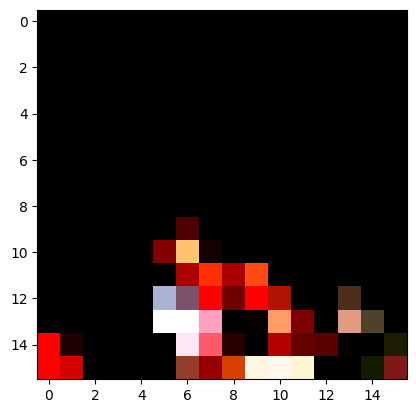

In [86]:
# 변환된 이미지 시각화
img_c, _ = cropped_cifar10[99]
img_c: torch.Tensor

plt.imshow(img_c.permute(1, 2, 0))
plt.show()

In [88]:
model_Big_crop = nn.Sequential(
    nn.Linear(3* 16 * 16, 512),
    nn.ReLU(),
    nn.Dropout(p = 0.4),
    nn.Linear(512, 512),
    nn.ReLU(),
    nn.Dropout(p = 0.4),
    nn.Linear(512, 256),
    nn.ReLU(),
    nn.Dropout(p = 0.4),
    nn.Linear(256, 256),
    nn.ReLU(),
    nn.Dropout(p = 0.4),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Dropout(p = 0.4),
    nn.Linear(128, 2)
)

model_Big_crop = model_Big_crop.to(device="cuda")

learning_rate = 0.005
optimizer = torch.optim.SGD(model_Big_crop.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss()

n_epochs = 200

for epoch in range(n_epochs):
    for imgs, labels in train_loader_crop:
        imgs: torch.Tensor
        labels: torch.Tensor
        imgs = imgs.to(device="cuda")
        labels = labels.to(device = "cuda")
        batch_size = imgs.shape[0]
        outputs = model_Big_crop(imgs.view(batch_size, -1))
        loss = loss_fn(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    print(f"Epoch :{epoch + 1}, Loss : {float(loss):.4f}")

Epoch :1, Loss : 0.6940
Epoch :2, Loss : 0.6827
Epoch :3, Loss : 0.6889
Epoch :4, Loss : 0.6947
Epoch :5, Loss : 0.6928
Epoch :6, Loss : 0.6861
Epoch :7, Loss : 0.6851
Epoch :8, Loss : 0.6719
Epoch :9, Loss : 0.6938
Epoch :10, Loss : 0.6712
Epoch :11, Loss : 0.6616
Epoch :12, Loss : 0.6581
Epoch :13, Loss : 0.6187
Epoch :14, Loss : 0.6775
Epoch :15, Loss : 0.6148
Epoch :16, Loss : 0.5155
Epoch :17, Loss : 0.5887
Epoch :18, Loss : 0.5245
Epoch :19, Loss : 0.5223
Epoch :20, Loss : 0.7878
Epoch :21, Loss : 0.6322
Epoch :22, Loss : 0.3993
Epoch :23, Loss : 0.4613
Epoch :24, Loss : 0.3984
Epoch :25, Loss : 0.3819
Epoch :26, Loss : 0.5877
Epoch :27, Loss : 0.4934
Epoch :28, Loss : 0.8084
Epoch :29, Loss : 0.4833
Epoch :30, Loss : 0.4650
Epoch :31, Loss : 0.6276
Epoch :32, Loss : 0.4045
Epoch :33, Loss : 0.6076
Epoch :34, Loss : 0.6850
Epoch :35, Loss : 0.7958
Epoch :36, Loss : 0.4926
Epoch :37, Loss : 0.4954
Epoch :38, Loss : 0.4488
Epoch :39, Loss : 0.4472
Epoch :40, Loss : 0.5388
Epoch :41

In [89]:
# model_Big_crop inference
correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in val_loader_crop:
        imgs: torch.Tensor
        labels: torch.Tensor
        imgs = imgs.to(device="cuda")
        labels = labels.to(device="cuda")
        batch_size = imgs.shape[0]
        outputs = model_Big_crop(imgs.view(batch_size, -1))
        _, predicted = torch.max(outputs, dim = 1)
        total += labels.shape[0]
        correct += int((predicted == labels).sum())

print(f"Accuracy : {correct / total :.4f}")

Accuracy : 0.7855


2. 손실 함수를 바꿔보자(아마도 MSE로).

    - a. 훈련 방식이 바뀌는가?

In [ ]:
train_loader.dataset[0]

(tensor([[[ 0.6143, -0.3224,  ..., -0.2748, -0.5447],
          [ 0.6620, -0.1478,  ..., -0.3224, -0.5764],
          ...,
          [ 0.5984,  0.4397,  ..., -0.4335,  0.0269],
          [ 0.9160,  0.8048,  ..., -0.5447, -0.0525]],
 
         [[ 1.3373,  0.2744,  ...,  0.3871,  0.0973],
          [ 1.4501,  0.5965,  ...,  0.3066,  0.0650],
          ...,
          [ 0.5482,  0.6609,  ...,  0.4033,  0.8864],
          [ 0.4838,  0.9508,  ...,  0.1617,  0.7576]],
 
         [[-0.4476, -0.7924,  ..., -0.6724, -0.8523],
          [-0.4476, -0.9723,  ..., -0.6275, -0.8523],
          ...,
          [-0.4326, -0.4776,  ..., -1.3021, -0.9873],
          [-0.1778,  0.0321,  ..., -1.3170, -1.0472]]]),
 1)

In [ ]:
test_imgs, test_labels = train_loader.dataset[1000]

test_labels

0

In [ ]:
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset

class OneHotTargetDataset(Dataset):
    def __init__(self, base_dataset, num_classes=2):
        self.base_dataset = base_dataset
        self.num_classes = num_classes

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        x, y = self.base_dataset[idx]
        y = F.one_hot(torch.tensor(y), num_classes=self.num_classes).float()
        return x, y

cifar2_oh = OneHotTargetDataset(cifar2, num_classes=2)
cifar2_oh_val = OneHotTargetDataset(cifar2_val, num_classes=2)
train_loader = torch.utils.data.DataLoader(cifar2_oh, batch_size=64, shuffle=True)
val_loader = torch.utils.data.DataLoader(cifar2_oh_val, batch_size=64, shuffle=False)

In [111]:
model_Big_mse = nn.Sequential(
    nn.Linear(3072, 1024),
    nn.ReLU(),
    nn.Dropout(p = 0.4),
    nn.Linear(1024, 1024),
    nn.ReLU(),
    nn.Dropout(p = 0.4),
    nn.Linear(1024, 512),
    nn.ReLU(),
    nn.Dropout(p = 0.4),
    nn.Linear(512, 512),
    nn.ReLU(),
    nn.Dropout(p = 0.4),
    nn.Linear(512, 128),
    nn.ReLU(),
    nn.Dropout(p = 0.4),
    nn.Linear(128, 2)
)

model_Big_mse = model_Big_mse.to(device="cuda")

learning_rate = 0.005
optimizer = torch.optim.SGD(model_Big_mse.parameters(), lr=learning_rate)
loss_fn = nn.MSELoss()

n_epochs = 200

train_loss_list, val_loss_list = [], []

for epoch in range(n_epochs):
    for imgs, labels in train_loader:
        imgs: torch.Tensor
        labels: torch.Tensor
        imgs = imgs.to(device="cuda")
        labels = labels.to(device = "cuda")
        batch_size = imgs.shape[0]
        outputs = model_Big_mse(imgs.view(batch_size, -1))
        train_loss = loss_fn(outputs, labels)
        
        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()
    
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs: torch.Tensor
            labels: torch.Tensor
            imgs, labels = imgs.to(device = "cuda"), labels.to(device = "cuda")
            batch_size = imgs.shape[0]
            outputs = model_Big_mse(imgs.view(batch_size, -1))
            val_loss = loss_fn(outputs, labels)
            
    train_loss_list.append(train_loss)  
    val_loss_list.append(val_loss)
            
        
    print(f"Epoch {epoch + 1}, train loss : {float(train_loss):.4f}, val loss : {float(val_loss):.4f}")

Epoch 1, train loss : 0.2631, val loss : 0.2814
Epoch 2, train loss : 0.2447, val loss : 0.2433
Epoch 3, train loss : 0.2276, val loss : 0.2428
Epoch 4, train loss : 0.2503, val loss : 0.2411
Epoch 5, train loss : 0.1992, val loss : 0.2353
Epoch 6, train loss : 0.2385, val loss : 0.1960
Epoch 7, train loss : 0.2103, val loss : 0.1984
Epoch 8, train loss : 0.1527, val loss : 0.2057
Epoch 9, train loss : 0.2179, val loss : 0.1765
Epoch 10, train loss : 0.2056, val loss : 0.1743
Epoch 11, train loss : 0.1827, val loss : 0.1932
Epoch 12, train loss : 0.1688, val loss : 0.1983
Epoch 13, train loss : 0.1848, val loss : 0.2176
Epoch 14, train loss : 0.1348, val loss : 0.2317
Epoch 15, train loss : 0.1669, val loss : 0.1421
Epoch 16, train loss : 0.0998, val loss : 0.1810
Epoch 17, train loss : 0.1076, val loss : 0.1573
Epoch 18, train loss : 0.1772, val loss : 0.1497
Epoch 19, train loss : 0.1561, val loss : 0.2193
Epoch 20, train loss : 0.1443, val loss : 0.1774
Epoch 21, train loss : 0.1583

In [117]:
train_loss_list_np, val_loss_list_np = [], []

for i in range(len(train_loss_list)):
    x: torch.Tensor
    y: torch.Tensor
    x, y = train_loss_list[i], val_loss_list[i]
    x, y = x.cpu().detach().numpy(), y.cpu().detach().numpy()
    train_loss_list_np.append(x)
    val_loss_list_np.append(y)

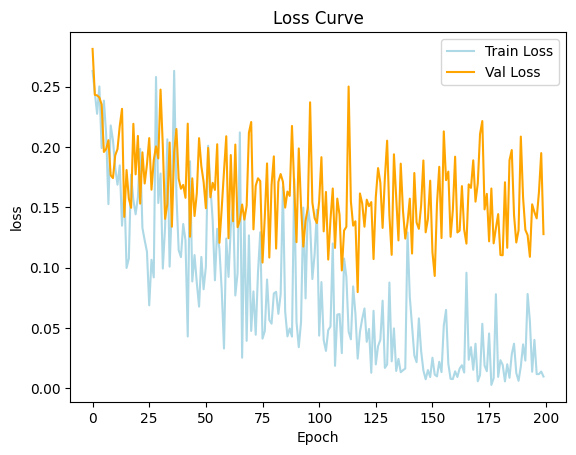

In [ ]:
import matplotlib.pyplot as plt

plt.plot(train_loss_list_np, color = 'lightblue', label = 'Train Loss')
plt.plot(val_loss_list_np, color = 'orange', label = 'Val Loss')
plt.xlabel("Epoch")
plt.ylabel("loss")
plt.title("Loss Curve")
plt.legend()
plt.show()


In [140]:
# model_Big_crop inference
correct = 0
total = 0

model_Big_mse.eval()

val_loader = torch.utils.data.DataLoader(cifar2_oh_val, batch_size=64, shuffle=False)

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs: torch.Tensor
        labels: torch.Tensor
        imgs = imgs.to(device="cuda")
        labels = labels.to(device="cuda")
        batch_size = imgs.shape[0]
        outputs = model_Big_mse(imgs.view(batch_size, -1))
        _, predicted = torch.max(outputs, dim = 1)
        _, true_cls = torch.max(labels, dim = 1) 
        total += labels.shape[0]
        correct += int((predicted == true_cls).sum())

print(f"Accuracy : {correct / total :.4f}")

Accuracy : 0.8770


3. 과적합이 일어나지 않을 정도로 신경망의 용량을 줄이는 것이 가능한가?

    - a. 이렇게 할 경우 검증셋에서의 모델 성능은 어떠한가?

## 7.5 핵심 요약

- 컴퓨터 비전은 딥러닝의 가장 주요한 응용 분야 중 하나다.
- 레이블된 여러 데이터셋이 공개되어 있으며 `torchvision`을 통해 접근 가능하다.
- `Dataset`과 `DataLoader`는 단순하면서도 효과적인 데이터 로딩과 샘플링을 위한 추상화를 제공한다.
- 분류 작업에서 소프트맥스 함수를 신경망의 출력단에 사용하면 결괏값을 확률로 해석할 때 필요한 요구사항을 만족할 수 있다. 이 경우 분류를 위한 이상적인 손실 함수는 소프트맥스의 출력을 '음이 아닌 로그 가능도 함수'의 입력으로 사용해서 얻을 수 있다. 파이토치에서 소프트맥스와 이런 손실값의 조합을 크로스엔트로피라고 부른다.
- 이미지를 픽셀값의 벡터로 간주하고 일반 숫자 데이터처럼 완전 연결 신경망으로 다뤄도 뭐라 할 사람은 없다. 하지만 이러면 데이터 내에서 공간적인 관계를 활용하기가 어려워진다.
- 단순한 모델은 `nn.Sequential`로 만들 수 있다.